# CIC-IoT-2023 — Data Pipeline: Exploration & Preprocessing
**Project:** Quantum-Inspired Federated IDS for IoT  
**Dataset:** CIC-IoT-2023 (34 attack classes + BenignTraffic)  
**Author:** SAIFBKKK
**Date:** 2025

---

## 🗺️ Overall Pipeline Overview

```
┌──────────────────────────────────────────────────────────────────────────────────────┐
│                        CIC-IoT-2023 DATA PIPELINE                                    │
│                                                                                      │
│  📁 RAW DATA                                                                        │
│  ┌──────────┐   ┌──────────┐   ┌──────────┐                                         │
│  │  train/  │   │  val/    │   │  test/   │  47 columns (46 float + 1 label)        │
│  │  .csv    │   │  .csv    │   │  .csv    │  5.49M / 1.18M / 1.18M rows             │
│  └────┬─────┘   └────┬─────┘   └────┬─────┘                                         │
│       └──────────────┼──────────────┘                                               │
│                      ▼                                                               │
│  ┌──────────────────────────────────┐                                                │
│  │  STEP 1 — LOAD                   │  Concat CSVs, verify shapes                   │
│  └──────────────────┬───────────────┘                                                │
│                     ▼                                                                │
│  ┌──────────────────────────────────┐                                                │
│  │  STEP 2 — EDA                    │  dtypes, NaN/Inf, duplicates                  │
│  │                                  │  class distribution, corr heatmap             │
│  │                                  │  constant + near-constant detection           │
│  └──────────────────┬───────────────┘                                                │
│                     ▼                                                                │
│  ┌──────────────────────────────────┐                                                │
│  │  STEP 3 — CLEAN                  │  Drop low-info features                    │
│  │                                  │    • constant                  │
│  │                                  │    • near-constant (>99.9%)               │
│  │                                  │  Drop redundant correlated feature          │
│  │                                  │                   │
│  │                                  │  Handle Inf values (replace → median)         │
│  │                                  │  Remove duplicate rows (train only)           │
│  │                                  │                       │
│  └──────────────────┬───────────────┘                                                │
│                     ▼                                                                │
│  ┌──────────────────────────────────┐                                                │
│  │  STEP 4 — LABEL ENCODING         │  Stable 34-class mapping from train           │
│  │                                  │  Save label_mapping_34.pkl                    │
│  └──────────────────┬───────────────┘                                                │
│                     ▼                                                                │
│  ┌──────────────────────────────────┐                                                │
│  │  STEP 5 — CLASS WEIGHTS          │  Balanced weights for 34 classes              │
│  │                                  │  Save class_weights_34.pkl                    │
│  └──────────────────┬───────────────┘                                                │
│                     ▼                                                                │
│  ┌──────────────────────────────────┐                                                │
│  │  STEP 6 — SCALING                │  RobustScaler (fit on train only)             │
│  │                                  │  Cast to float32                              │
│  │                                  │  Save scaler_robust.pkl                       │
│  └──────────────────┬───────────────┘                                                │
│                     ▼                                                                │
│  ┌──────────────────────────────────┐                                                │
│  │  STEP 7 — SAVE ARTIFACTS         │  .npz, .pkl (scaler, labels, weights,        │
│  │                                  │   feature names) + sanity check              │
│  └──────────────────┬───────────────┘                                                │
│                     ▼                                                                │
│  ┌──────────────────────────────────┐                                                │
│  │  NEXT → 02_FL_Partitioning.ipynb │  Non-IID Dirichlet client simulation          │
│  └──────────────────────────────────┘                                                │
└──────────────────────────────────────────────────────────────────────────────────────┘
```


# PART 1 — DATA EXPLORATION

## Section 0 — Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import torch
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight

# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Paths ---
BASE_PATH = r"C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23"

print("Configuration loaded. SEED =", SEED)

Configuration loaded. SEED = 42


## Section 1 — Data Loading

In [2]:
def load_folder(folder_path: str) -> pd.DataFrame:
    """Load and concatenate all CSV files from a folder (sorted for reproducibility)."""
    all_files = sorted([
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.endswith(".csv")
    ])
    df_list = []
    for file in all_files:
        print(f"  Loading: {file}")
        df_list.append(pd.read_csv(file))
    return pd.concat(df_list, ignore_index=True)


print("Loading train split...")
train_df = load_folder(os.path.join(BASE_PATH, "train"))

print("Loading validation split...")
val_df = load_folder(os.path.join(BASE_PATH, "validation"))

print("Loading test split...")
test_df = load_folder(os.path.join(BASE_PATH, "test"))

print("\n--- Shapes ---")
print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print(f"Test       : {test_df.shape}")

Loading train split...
  Loading: C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\train\train.csv
Loading validation split...
  Loading: C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\validation\validation.csv
Loading test split...
  Loading: C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23\test\test.csv

--- Shapes ---
Train      : (5491971, 47)
Validation : (1176851, 47)
Test       : (1176851, 47)


## Section 2 — Structural Verification

**Checks:** column types · NaN · Inf · duplicate rows · split label consistency

In [3]:
# --- First look ---
print("=== First rows ===")
display(train_df.head())

print("\n=== Column types ===")
print(train_df.dtypes.value_counts())

print("\n=== Full info ===")
train_df.info()

=== First rows ===


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood



=== Column types ===
float64    46
object      1
Name: count, dtype: int64

=== Full info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5491971 entries, 0 to 5491970
Data columns (total 47 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flow_duration    float64
 1   Header_Length    float64
 2   Protocol Type    float64
 3   Duration         float64
 4   Rate             float64
 5   Srate            float64
 6   Drate            float64
 7   fin_flag_number  float64
 8   syn_flag_number  float64
 9   rst_flag_number  float64
 10  psh_flag_number  float64
 11  ack_flag_number  float64
 12  ece_flag_number  float64
 13  cwr_flag_number  float64
 14  ack_count        float64
 15  syn_count        float64
 16  fin_count        float64
 17  urg_count        float64
 18  rst_count        float64
 19  HTTP             float64
 20  HTTPS            float64
 21  DNS              float64
 22  Telnet           float64
 23  SMTP             float64
 24  SSH    

In [ ]:
# --- NaN & Inf ---
nan_count = train_df.isna().sum().sum()
inf_count = np.isinf(train_df.select_dtypes(include=[float])).sum().sum()
print(f"NaN values : {nan_count}")
print(f"Inf values : {inf_count}")

NaN values : 0
Inf values : 0


In [ ]:
# --- Duplicate rows ---
print(f"Duplicate rows — Train: {train_df.duplicated().sum():,} "
      f"| Val: {val_df.duplicated().sum():,} "
      f"| Test: {test_df.duplicated().sum():,}")

Duplicate rows — Train: 134,565 | Val: 6,297 | Test: 6,384


In [ ]:
# --- Split label consistency ---
train_classes = set(train_df["label"].unique())
val_classes   = set(val_df["label"].unique())
test_classes  = set(test_df["label"].unique())

print("Classes in val  but NOT in train:", val_classes  - train_classes)
print("Classes in test but NOT in train:", test_classes - train_classes)
print("Classes in train but NOT in val  :", train_classes - val_classes)
print("Classes in train but NOT in test :", train_classes - test_classes)

Classes in val  but NOT in train: set()
Classes in test but NOT in train: set()
Classes in train but NOT in val  : set()
Classes in train but NOT in test : set()


## Section 3 — Class Distribution & Imbalance

In [ ]:
# --- Class list & benign check ---
labels = train_df["label"].unique()
print(f"Total classes : {len(labels)}")
print("Sorted labels :", sorted(labels))

if any("BENIGN" in str(l).upper() for l in labels):
    print("\n BenignTraffic found — binary and multi-class classification both supported.")
else:
    print("\n No BENIGN class found.")

Total classes : 34
Sorted labels : ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Mirai-greeth_flood', 'Mirai-greip_flood', 'Mirai-udpplain', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS']

✅ BenignTraffic found — binary and multi-class classification both supported.


In [8]:
# --- Count & percentage ---
dist     = train_df["label"].value_counts()
dist_pct = train_df["label"].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({"count": dist, "percent_%": dist_pct.round(3)})
display(class_summary)

print(f"\nBenignTraffic: {dist.get('BenignTraffic', 0):,} samples "
      f"({dist_pct.get('BenignTraffic', 0):.2f}%)")
print("→ Strong imbalance: use Macro F1-score, not accuracy.")

,count,percent_%
label,,
DDoS-ICMP_Flood,848088,15.442
DDoS-UDP_Flood,637558,11.609
DDoS-TCP_Flood,528499,9.623
DDoS-PSHACK_Flood,481254,8.763
DDoS-SYN_Flood,478653,8.716
DDoS-RSTFINFlood,475441,8.657
DDoS-SynonymousIP_Flood,422083,7.685
DoS-UDP_Flood,390422,7.109
DoS-TCP_Flood,314174,5.721



BenignTraffic: 129,538 samples (2.36%)
→ Strong imbalance: use Macro F1-score, not accuracy.


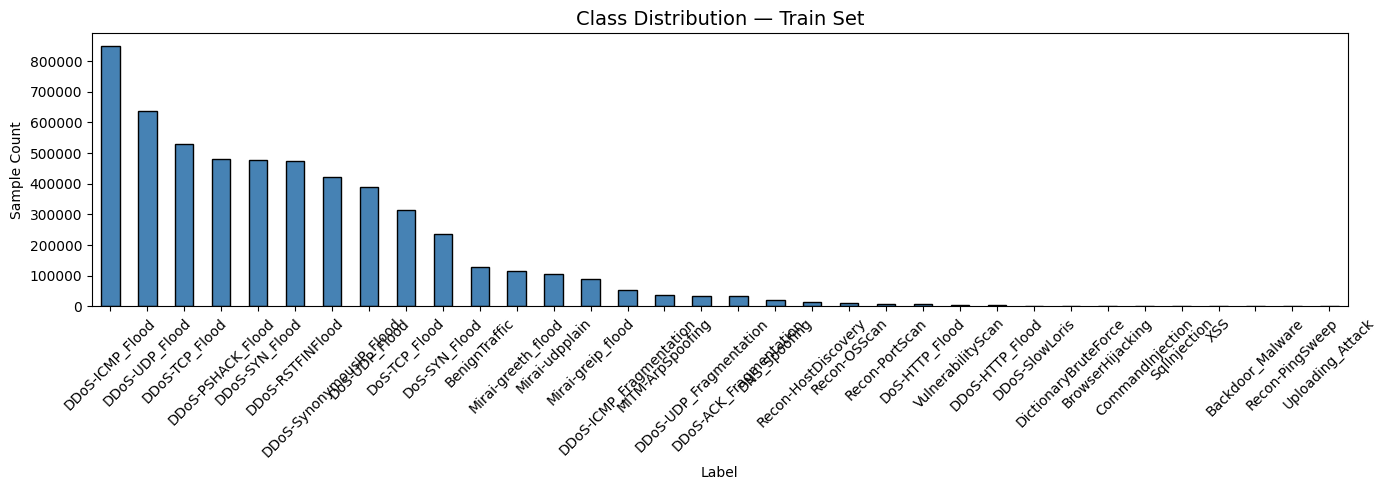

In [9]:
# --- Bar chart ---
fig, ax = plt.subplots(figsize=(14, 5))
dist.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Class Distribution — Train Set", fontsize=14)
ax.set_xlabel("Label")
ax.set_ylabel("Sample Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

## Section 4 — Feature Analysis

Identify features to drop before training: **constant**, **near-constant**, and **perfectly correlated**.

In [10]:
# --- Descriptive statistics ---
display(train_df.describe().T.style.background_gradient(cmap="Blues"))

,count,mean,std,min,25%,50%,75%,max
flow_duration,5491971.000000,5.657345,274.915671,0.000000,0.000000,0.000000,0.105029,99435.761782
Header_Length,5491971.000000,76871.466912,461500.517376,0.000000,54.000000,54.000000,300.130000,9890104.900000
Protocol Type,5491971.000000,9.066457,8.943837,0.000000,6.000000,6.000000,14.440000,47.000000
Duration,5491971.000000,66.361414,14.065181,0.000000,64.000000,64.000000,64.000000,255.000000
Rate,5491971.000000,9049.941566,99863.996716,0.000000,2.093860,15.785983,117.875472,8388608.000000
Srate,5491971.000000,9049.941566,99863.996716,0.000000,2.093860,15.785983,117.875472,8388608.000000
Drate,5491971.000000,0.000003,0.001849,0.000000,0.000000,0.000000,0.000000,2.679210
fin_flag_number,5491971.000000,0.086501,0.281102,0.000000,0.000000,0.000000,0.000000,1.000000
syn_flag_number,5491971.000000,0.207114,0.405238,0.000000,0.000000,0.000000,0.000000,1.000000
rst_flag_number,5491971.000000,0.090424,0.286789,0.000000,0.000000,0.000000,0.000000,1.000000


In [ ]:
# --- Constant features (nunique == 1) ---
nunique = train_df.nunique()
constant_cols = nunique[nunique <= 1]
print("Constant columns (will be dropped):")
print(constant_cols)

Constant columns (will be dropped):
Telnet    1
IRC       1
dtype: int64


In [12]:
# --- Near-constant features (>99.9% same value) ---
near_constant = []
for col in train_df.select_dtypes(include=[float, int]).columns:
    top_freq = train_df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.999:
        near_constant.append((col, round(top_freq * 100, 3)))

print("Near-constant features (>99.9% same value):")
for col, pct in sorted(near_constant, key=lambda x: -x[1]):
    print(f"  {col:<22}: {pct}% same value")

Near-constant features (>99.9% same value):
  ece_flag_number       : 100.0% same value
  cwr_flag_number       : 100.0% same value
  Telnet                : 100.0% same value
  SMTP                  : 100.0% same value
  IRC                   : 100.0% same value
  DHCP                  : 100.0% same value
  SSH                   : 99.995% same value
  Drate                 : 99.994% same value
  ARP                   : 99.993% same value
  IPv                   : 99.989% same value
  LLC                   : 99.989% same value
  DNS                   : 99.987% same value


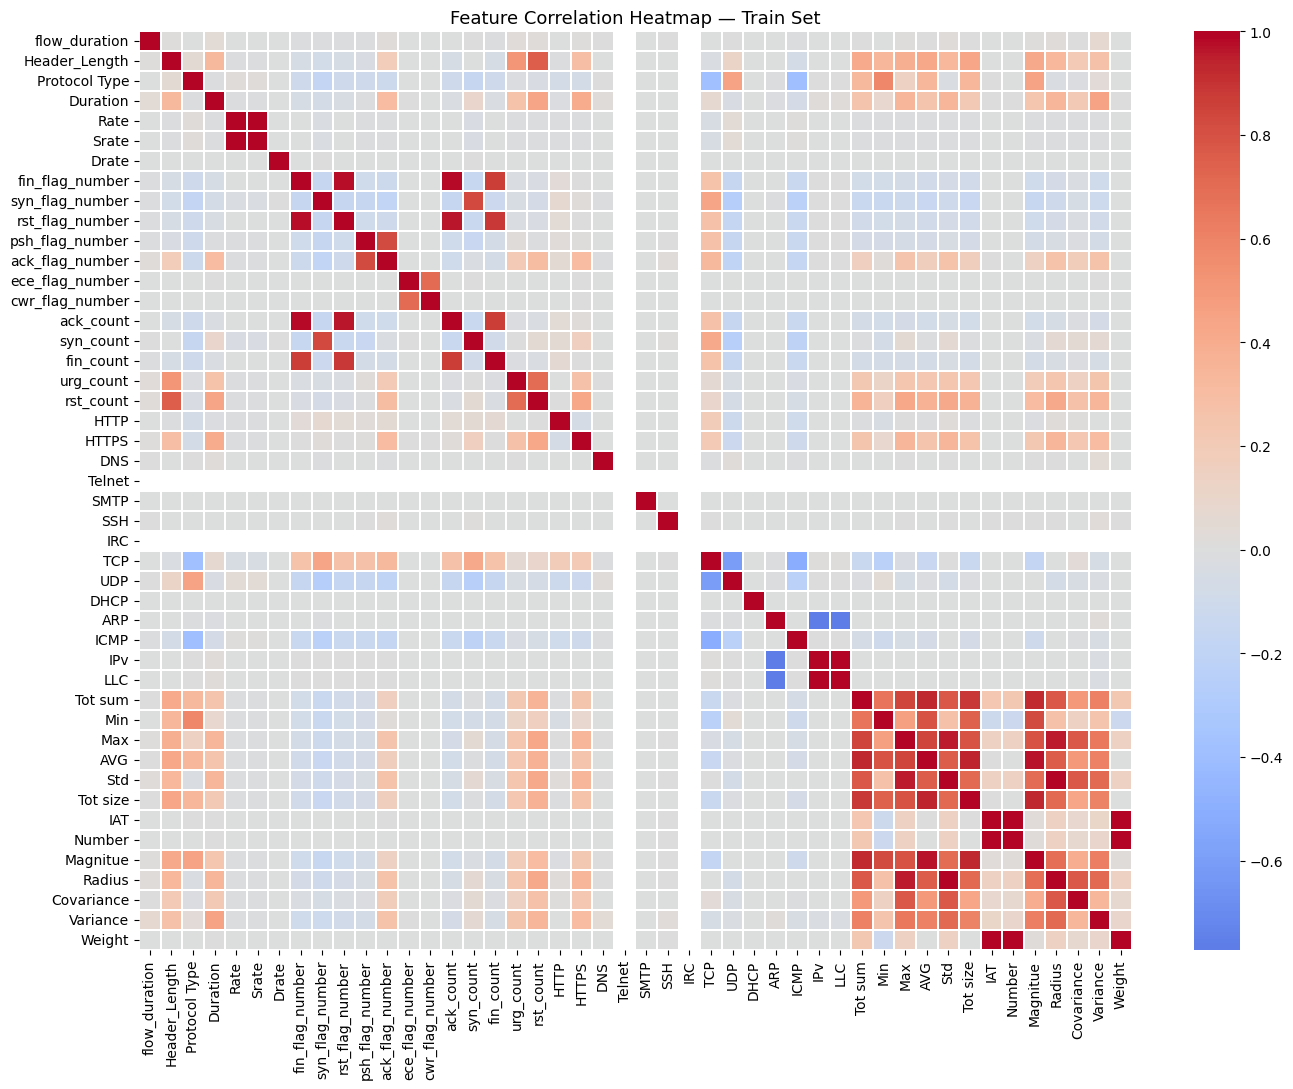

In [13]:
# --- Correlation heatmap ---
numeric_cols = train_df.drop(columns=["label"]).columns
corr = train_df[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Feature Correlation Heatmap — Train Set", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [14]:
# --- Highly correlated pairs (|r| > 0.95) ---
CORR_THRESHOLD = 0.95
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = abs(corr.iloc[i, j])
        if r > CORR_THRESHOLD:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(r, 4)))

print(f"Highly correlated pairs (|r| > {CORR_THRESHOLD}):")
for a, b, v in sorted(high_corr_pairs, key=lambda x: -x[2]):
    tag = "  ← DROP one" if v == 1.0 else ""
    print(f"  {a:<22}  <-->  {b:<22}  r = {v}{tag}")

Highly correlated pairs (|r| > 0.95):
  Rate                    <-->  Srate                   r = 1.0  ← DROP one
  IPv                     <-->  LLC                     r = 1.0  ← DROP one
  Std                     <-->  Radius                  r = 1.0  ← DROP one
  Number                  <-->  Weight                  r = 0.9996
  IAT                     <-->  Weight                  r = 0.9973
  IAT                     <-->  Number                  r = 0.996
  fin_flag_number         <-->  ack_count               r = 0.9861
  fin_flag_number         <-->  rst_flag_number         r = 0.9757
  AVG                     <-->  Magnitue                r = 0.9683
  rst_flag_number         <-->  ack_count               r = 0.9622
  Max                     <-->  Std                     r = 0.9525
  Max                     <-->  Radius                  r = 0.9525


### 🔍 Feature Removal Decision

Based on EDA results, the following features will be **removed before training**:

| Reason | Features dropped |
|--------|------------------|
| **Constant** (1 unique value) | `Telnet`, `IRC` |
| **Near-constant** (>99.9%) | `Drate`, `ece_flag_number`, `cwr_flag_number`, `DNS`, `SMTP`, `SSH`, `DHCP`, `ARP` |
| **Perfect correlation** (r=1.0) | `Srate` (duplicate of `Rate`), `LLC` (duplicate of `IPv`), `Radius` (duplicate of `Std`) |

**Total removed: 13 features → 33 features remaining**

> Note on `IPv`/`LLC` and `Std`/`Radius`: keep the semantically more interpretable one (`IPv`, `Std`).
> For `Rate`/`Srate`: keep `Rate` (total rate), drop `Srate` (source rate — subset).

---

## 📋 EDA Findings Summary (from exploration run)

| Finding | Detail | Action |
|---------|--------|--------|
| **Duplicate rows** | 134,565 train / 6,297 val / 6,384 test | Drop from train only |
| **Split consistency** | No unseen classes in val or test | ✅ No action needed |
| **NaN / Inf values** | None detected | ✅ No imputation needed |
| **Constant features** | `Telnet`, `IRC` (1 unique value) | Drop |
| **Near-constant features** | 8 cols >99.9% same value | Drop |
| **r = 1.0 pairs** | `Rate ↔ Srate`, `IPv ↔ LLC`, `Std ↔ Radius` | Drop one from each pair |
| **High corr (r>0.95)** | 9 additional pairs | Keep but document |
| **BenignTraffic** | ~2.36% of train | Use class weights + Macro F1 |
| **Feature scales** | IAT ~8e7, Rate ~8e6 | RobustScaler mandatory |

---

---
# PART 2 — DATA PREPROCESSING

## Objective

Transform raw CIC-IoT-2023 data into clean, numerically stable, FL-ready arrays for 34-class IDS.

---

## Section 1 — Drop Non-Informative & Redundant Features

In [15]:
# Features to drop — justified by EDA
DROP_CONSTANT = ["Telnet", "IRC"]  # 1 unique value

DROP_NEAR_CONSTANT = [
    "Drate",          # 99.994% same value
    "ece_flag_number",# 100% same value
    "cwr_flag_number",# 100% same value
    "DNS",            # 99.987% same value
    "SMTP",           # 100% same value
    "SSH",            # 99.995% same value
    "DHCP",           # 100% same value
    "ARP",            # 99.993% same value
]

# Perfect correlates — keep the more interpretable feature of each pair
DROP_CORRELATED = [
    "Srate",   # r=1.0 with Rate   → keep Rate
    "LLC",     # r=1.0 with IPv    → keep IPv
    "Radius",  # r=1.0 with Std    → keep Std
]

ALL_DROP = DROP_CONSTANT + DROP_NEAR_CONSTANT + DROP_CORRELATED

print(f"Dropping {len(ALL_DROP)} features:")
for f in ALL_DROP:
    print(f"  - {f}")

train_df = train_df.drop(columns=ALL_DROP)
val_df   = val_df.drop(columns=ALL_DROP)
test_df  = test_df.drop(columns=ALL_DROP)

FEATURE_COLS = [c for c in train_df.columns if c != "label"]
print(f"\nRemaining features: {len(FEATURE_COLS)}")

Dropping 13 features:
  - Telnet
  - IRC
  - Drate
  - ece_flag_number
  - cwr_flag_number
  - DNS
  - SMTP
  - SSH
  - DHCP
  - ARP
  - Srate
  - LLC
  - Radius

Remaining features: 33


## Section 2 — Handle Infinite Values

Replace `±Inf` with `NaN`, then impute with the training-set column median.
Inf values cause `RobustScaler` to fail silently or crash.

In [16]:
def replace_inf_with_median(df: pd.DataFrame, medians: dict = None) -> (pd.DataFrame, dict):
    """Replace Inf → NaN → median. Returns df and median dict (for reuse on val/test)."""
    num_cols = df.select_dtypes(include=[float]).columns
    df = df.copy()
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
    if medians is None:  # fit on train
        medians = df[num_cols].median().to_dict()
    df[num_cols] = df[num_cols].fillna(pd.Series(medians))
    return df, medians


train_df, train_medians = replace_inf_with_median(train_df)
val_df,   _             = replace_inf_with_median(val_df,  train_medians)
test_df,  _             = replace_inf_with_median(test_df, train_medians)

# Final assertion
assert np.isinf(train_df.select_dtypes(include=[float])).sum().sum() == 0
assert train_df.isna().sum().sum() == 0
print("✅ No Inf or NaN remaining in any split.")

✅ No Inf or NaN remaining in any split.


## Section 3 — Remove Duplicate Rows (Train Only)

134,565 duplicate rows detected in the training set. Removing them reduces noise and prevents
implicit overrepresentation of certain patterns.

> Val and test duplicates are **kept** to preserve the integrity of the evaluation distribution.

In [17]:
before = len(train_df)
train_df = train_df.drop_duplicates()
after = len(train_df)
print(f"Duplicates removed : {before - after:,}")
print(f"Train size after   : {after:,}")

Duplicates removed : 134,565
Train size after   : 5,357,406


## Section 4 — Label Encoding (34 Classes, Stable)

In [18]:
# Build mapping from train only (sorted alphabetically for stability)
labels_sorted = sorted(train_df["label"].unique())
label_to_id   = {lab: i for i, lab in enumerate(labels_sorted)}
id_to_label   = {i: lab for lab, i in label_to_id.items()}

print(f"Number of classes: {len(label_to_id)}")
for i, lab in id_to_label.items():
    print(f"  [{i:2d}] {lab}")

Number of classes: 34
  [ 0] Backdoor_Malware
  [ 1] BenignTraffic
  [ 2] BrowserHijacking
  [ 3] CommandInjection
  [ 4] DDoS-ACK_Fragmentation
  [ 5] DDoS-HTTP_Flood
  [ 6] DDoS-ICMP_Flood
  [ 7] DDoS-ICMP_Fragmentation
  [ 8] DDoS-PSHACK_Flood
  [ 9] DDoS-RSTFINFlood
  [10] DDoS-SYN_Flood
  [11] DDoS-SlowLoris
  [12] DDoS-SynonymousIP_Flood
  [13] DDoS-TCP_Flood
  [14] DDoS-UDP_Flood
  [15] DDoS-UDP_Fragmentation
  [16] DNS_Spoofing
  [17] DictionaryBruteForce
  [18] DoS-HTTP_Flood
  [19] DoS-SYN_Flood
  [20] DoS-TCP_Flood
  [21] DoS-UDP_Flood
  [22] MITM-ArpSpoofing
  [23] Mirai-greeth_flood
  [24] Mirai-greip_flood
  [25] Mirai-udpplain
  [26] Recon-HostDiscovery
  [27] Recon-OSScan
  [28] Recon-PingSweep
  [29] Recon-PortScan
  [30] SqlInjection
  [31] Uploading_Attack
  [32] VulnerabilityScan
  [33] XSS


In [19]:
y_train = train_df["label"].map(label_to_id).values
y_val   = val_df["label"].map(label_to_id).values
y_test  = test_df["label"].map(label_to_id).values

X_train = train_df.drop(columns=["label"])
X_val   = val_df.drop(columns=["label"])
X_test  = test_df.drop(columns=["label"])

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")

with open("label_mapping_34.pkl", "wb") as f:
    pickle.dump({"label_to_id": label_to_id, "id_to_label": id_to_label}, f)
print("\n✅ label_mapping_34.pkl saved.")

X_train : (5357406, 33)  |  y_train : (5357406,)
X_val   : (1176851, 33)    |  y_val   : (1176851,)
X_test  : (1176851, 33)   |  y_test  : (1176851,)

✅ label_mapping_34.pkl saved.


## Section 5 — Class Weights

Computed with `sklearn.utils.class_weight.compute_class_weight('balanced')`.  
Pass as `weight=` to `torch.nn.CrossEntropyLoss` during training.

In [20]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(label_to_id)),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32)

weight_df = pd.DataFrame({
    "id"    : np.arange(len(label_to_id)),
    "label" : [id_to_label[i] for i in range(len(label_to_id))],
    "weight": class_weights_array.round(4)
}).sort_values("weight", ascending=False)

print("Class weights (higher = rarer class):")
display(weight_df)

with open("class_weights_34.pkl", "wb") as f:
    pickle.dump(class_weights_array, f)
print("✅ class_weights_34.pkl saved.")

Class weights (higher = rarer class):


,id,label,weight
31,31,Uploading_Attack,1133.6026
28,28,Recon-PingSweep,643.1460
0,0,Backdoor_Malware,406.1102
33,33,XSS,388.1053
30,30,SqlInjection,271.6737
3,3,CommandInjection,258.7369
2,2,BrowserHijacking,243.9176
17,17,DictionaryBruteForce,105.8943
11,11,DDoS-SlowLoris,58.5547
5,5,DDoS-HTTP_Flood,47.8793


✅ class_weights_34.pkl saved.


## Section 6 — Feature Scaling (RobustScaler)

**Why RobustScaler?**
- Features like `IAT` (~8e7) and `Rate` (~8e6) have extreme ranges with outliers.
- RobustScaler uses **median + IQR** — resistant to outliers unlike `StandardScaler`.

>  Scaler is **fitted on training data only**, then applied to val and test to prevent data leakage.

In [21]:
scaler = RobustScaler()

X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

print(f"X_train_s : {X_train_s.shape}  dtype={X_train_s.dtype}")
print(f"X_val_s   : {X_val_s.shape}    dtype={X_val_s.dtype}")
print(f"X_test_s  : {X_test_s.shape}   dtype={X_test_s.dtype}")

with open("scaler_robust.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("\n✅ scaler_robust.pkl saved.")

X_train_s : (5357406, 33)  dtype=float32
X_val_s   : (1176851, 33)    dtype=float32
X_test_s  : (1176851, 33)   dtype=float32

✅ scaler_robust.pkl saved.


## Section 7 — Save All Artifacts

In [ ]:
# --- Preprocessed arrays ---
np.savez_compressed(
    "ciciot23_34class_preprocessed.npz",
    X_train=X_train_s, y_train=y_train,
    X_val=X_val_s,     y_val=y_val,
    X_test=X_test_s,   y_test=y_test
)
print(" ciciot23_34class_preprocessed.npz saved.")

# --- Feature names (needed for SHAP / model interpretation later) ---
with open("feature_names.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)
print(" feature_names.pkl saved.")

print("\n--- Complete artifact list ---")
artifacts = [
    ("ciciot23_34class_preprocessed.npz", "X/y arrays for train, val, test"),
    ("label_mapping_34.pkl",               "label ↔ int mapping (34 classes)"),
    ("scaler_robust.pkl",                  "RobustScaler fitted on train"),
    ("class_weights_34.pkl",               "Balanced class weights for loss function"),
    ("feature_names.pkl",                  "33 feature names after cleaning"),
]
for fname, desc in artifacts:
    print(f"  {fname:<45} → {desc}")

✅ ciciot23_34class_preprocessed.npz saved.
✅ feature_names.pkl saved.

--- Complete artifact list ---
  ciciot23_34class_preprocessed.npz             → X/y arrays for train, val, test
  label_mapping_34.pkl                          → label ↔ int mapping (34 classes)
  scaler_robust.pkl                             → RobustScaler fitted on train
  class_weights_34.pkl                          → Balanced class weights for loss function
  feature_names.pkl                             → 33 feature names after cleaning


## Section 8 — Final Sanity Check

In [25]:
# Reload and validate
data = np.load("ciciot23_34class_preprocessed.npz")

print("=== Reload verification ===")
for key in data.files:
    arr = data[key]
    print(f"  {key:<12}: shape={arr.shape}, dtype={arr.dtype}")
    if "X" in key:
        assert not np.any(np.isnan(arr)), f"NaN found in {key}!"
        assert not np.any(np.isinf(arr)), f"Inf found in {key}!"

# Verify feature count
assert data["X_train"].shape[1] == X_train.shape[1], \
    f"Feature count mismatch! Expected {X_train.shape[1]}, got {data['X_train'].shape[1]}"

# Verify label range
assert data["y_train"].max() == len(label_to_id) - 1
assert data["y_train"].min() == 0

print("\n✅ All assertions passed. Pipeline complete.")
print(f"\nFinal feature count : {data['X_train'].shape[1]}")
print(f"Number of classes   : {len(label_to_id)}")
print(f"Train samples       : {data['X_train'].shape[0]:,}")

=== Reload verification ===
  X_train     : shape=(5357406, 33), dtype=float32
  y_train     : shape=(5357406,), dtype=int64
  X_val       : shape=(1176851, 33), dtype=float32
  y_val       : shape=(1176851,), dtype=int64
  X_test      : shape=(1176851, 33), dtype=float32
  y_test      : shape=(1176851,), dtype=int64

✅ All assertions passed. Pipeline complete.

Final feature count : 33
Number of classes   : 34
Train samples       : 5,357,406


## Section 9 — Preprocessing Summary

| Step | Action | Result |
|------|--------|--------|
| Load | Concat CSVs from train/val/test folders | 5.49M / 1.18M / 1.18M rows |
| EDA | Shape, dtypes, NaN, Inf, duplicates, distribution | No NaN/Inf; 134K train duplicates; 34 classes |
| Drop constant | Remove `Telnet`, `IRC` | -2 features |
| Drop near-constant | Remove 8 cols >99.9% same value | -8 features |
| Drop correlated | Remove `Srate`, `LLC`, `Radius` (r=1.0 pairs) | -3 features |
| Inf handling | Replace ±Inf with column median (train-fitted) | 0 Inf remaining |
| Deduplication | Remove 134,565 train duplicates | Cleaner training signal |
| Label encoding | Stable sorted 34-class int mapping | `label_mapping_34.pkl` |
| Class weights | `balanced` strategy, 34 classes | `class_weights_34.pkl` |
| Scaling | RobustScaler, fit on train only, float32 | `scaler_robust.pkl` |
| Save | `.npz` + 4 `.pkl` artifacts | All splits preserved |

**Final shape:** `X_train (N × 33)`, `X_val (N × 33)`, `X_test (N × 33)` — 34 class labels.
